In [1]:
# decided to use county for final dataset
# apparently can be done with geopandas if we have data about county boundaries to standardize location for different datasets

# think I'm also doing protected areas

In [2]:
# imports
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
wetlands_data = Path.cwd().parent.joinpath('data', 'nwi_wetlands', 'osm_wetlands_usa.csv')

# 1. Load Dataset

In [4]:
df = pd.read_csv(wetlands_data)
df.head()

,id,lat,lon,name,wetland,natural
0,1380083446,37.597754,-122.499645,Lake Mathilda,swamp,wetland
1,1381010770,37.611453,-122.495585,NaN,marsh,wetland
2,1127916788,37.626035,-122.492626,NaN,saltmarsh,wetland
3,934768634,38.027352,-122.961100,NaN,tidalflat,wetland
4,934768635,38.027558,-122.961533,NaN,reedbed,wetland


In [5]:
print(df.shape)
print(df.columns)

(517688, 6)
Index(['id', 'lat', 'lon', 'name', 'wetland', 'natural'], dtype='object')


In [6]:
df.dtypes

id           int64
lat        float64
lon        float64
name        object
wetland     object
natural     object
dtype: object

# 2. Cleaning

In [7]:
df.isna().sum()

id              0
lat             0
lon             0
name       514817
wetland    256053
natural         0
dtype: int64

In [8]:
# looking at rows with identical data, except possibly for id
duplicates = df[df.duplicated(subset=['lat', 'lon', 'name', 'wetland', 'natural'], keep=False)]
print(duplicates.sort_values(by=['lat', 'lon']).head(6))

# to view full list, uncomment below
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     print(duplicates.sort_values(by=['lat', 'lon']))

               id        lat        lon                name wetland  natural
205785   49613495  29.988428 -91.255339                 NaN   marsh  wetland
517683   49613495  29.988428 -91.255339                 NaN   marsh  wetland
202678  166981312  29.996713 -94.747738  Turkey Creek Marsh     NaN  wetland
517551  166981312  29.996713 -94.747738  Turkey Creek Marsh     NaN  wetland
205532   90747270  29.996861 -91.632835                 NaN     NaN  wetland
517675   90747270  29.996861 -91.632835                 NaN     NaN  wetland


In [9]:
# dropping duplicates
df = df.drop_duplicates(subset=['lat', 'lon', 'name', 'wetland', 'natural'], keep='first')

In [10]:
# all values for 'natural' column are 'wetland', dropping the column
print(df['natural'].value_counts())
df = df.drop(columns='natural')

natural
wetland    517549
Name: count, dtype: int64


In [11]:
# filter to continental US bounds (box) only
df = df[
    (df['lat'] >= 24.5) &   # Florida
    (df['lat'] <= 49.4) &   # Minnesota
    (df['lon'] >= -124.8) & # Washington
    (df['lon'] <= -66.99)   # Maine
]

### Cleaning `Wetland` Column

In [12]:
# display values for 'wetland' column
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     print(df['wetland'].value_counts())

In [13]:
# function to normalize 'wetland' column, update as needed
def normalize_wetland(val):
    """
    Normalizes raw OSM wetland tag values into a set of standard ecological categories.
    
    Strategy: keyword-based rules with manual overrides for edge cases.
    Rules are ordered from MOST specific to LEAST specific to avoid
    premature matches (e.g. 'saltmarsh' must be checked before 'marsh').
    
    Final categories:
        swamp, marsh, saltmarsh, wet_meadow, bog, fen, tidalflat,
        reedbed, mangrove, carolina_bay, oxbow, vernal_pool,
        floodplain, estuary, unclassified

        oxbow? floodplain? estuary? unclassified?
        string_bog, rain_garden, mud, pond
    """

    # converting nulls to 'unclassified'
    if pd.isna(val):
        return 'unclassified'

    val = val.lower().strip()

    # manual conversion
    overrides = {
        # 'string_bog' is still a bog
        'string_bog': 'bog',
        # 'peat_bog' is a bog
        'peat_bog': 'bog',  

        # 'carr' and 'seepage_carr' are wooded fens
        'carr': 'fen',
        'seepage_carr': 'fen',

        # 'mudflat' to 'mud'
        'mudflat': 'mud',

        # 'spung' is a NJ vernal pool
        'spung': 'vernal_pool',
        'vern': 'vernal_pool',
        'vernalpool': 'vernal_pool',
        'vernal_marsh': 'vernal_pool',

        # probable typos:
        'marash': 'marsh',
        'mars': 'marsh',

        'saltmars': 'saltmarsh',

        'swa': 'swamp',
        'swp': 'swamp',
        'swqam': 'swamp'
    }

    if val in overrides:
        return overrides[val]

    # keyword rules, ordering below can matter (e.g. 'marsh' in 'saltmarsh')
    if 'saltmarsh' in val or 'salt_marsh' in val:
        return 'saltmarsh'

    if 'mangrove' in val:
        return 'mangrove'

    if 'tidalflat' in val or 'tidal_flat' in val or 'tidal flat' in val:
        return 'tidalflat'

    if 'reedbed' in val or 'reed_bed' in val:
        return 'reedbed'

    if 'carolina' in val and ('bay' in val):
        return 'carolina_bay'

    if 'bog' in val:
        return 'bog'

    if 'fen' in val:
        return 'fen'

    if 'vernal' in val:
        return 'vernal_pool'

    if 'meadow' in val or 'wet_meadow' in val:
        return 'wet_meadow'

    if 'swamp' in val:
        return 'swamp'

    if 'marsh' in val:
        return 'marsh'
    
    if 'pond' in val:
        return 'pond'
    
    if 'mud' in val:
        return 'mud'

    return 'unclassified'

In [14]:
# normalizing 'wetland' column
df['wetland_normalized'] = df['wetland'].apply(normalize_wetland)

In [15]:
# viewing normalizing changes
# print('=== Normalized value counts ===')
# print(df['wetland_normalized'].value_counts())
# print()

# print('=== Mapping (raw -> normalized) ===')
# mapping_check = df.groupby(['wetland', 'wetland_normalized']).size().reset_index(name='count')
# print(mapping_check.to_string())

In [16]:
df['wetland_normalized'].value_counts()

wetland_normalized
unclassified    256021
swamp           159556
marsh            58429
wet_meadow       22571
saltmarsh         9359
tidalflat         3604
reedbed           3019
bog               2747
fen               1528
mangrove           420
mud                113
carolina_bay        60
pond                16
vernal_pool         15
Name: count, dtype: int64

# 3. EDA

In [17]:
print(df.shape)
print(df.columns)
print(df.isna().sum())

(517458, 6)
Index(['id', 'lat', 'lon', 'name', 'wetland', 'wetland_normalized'], dtype='object')
id                         0
lat                        0
lon                        0
name                  514618
wetland               255934
wetland_normalized         0
dtype: int64


In [18]:
# creating regions as a proxy for comparison
def assign_region(row):
    if row['lat'] >= 40 and row['lon'] >= -98.5: return 'Northeast'
    if row['lat'] >= 40 and row['lon'] < -98.5:  return 'Northwest'
    if row['lat'] < 40  and row['lon'] >= -98.5: return 'Southeast'
    return 'Southwest'
df['region'] = df.apply(assign_region, axis=1)

REGION_COLORS = {
    'Northeast': 'steelblue',
    'Southeast': 'mediumseagreen',
    'Northwest': 'coral',
    'Southwest': 'goldenrod',
}

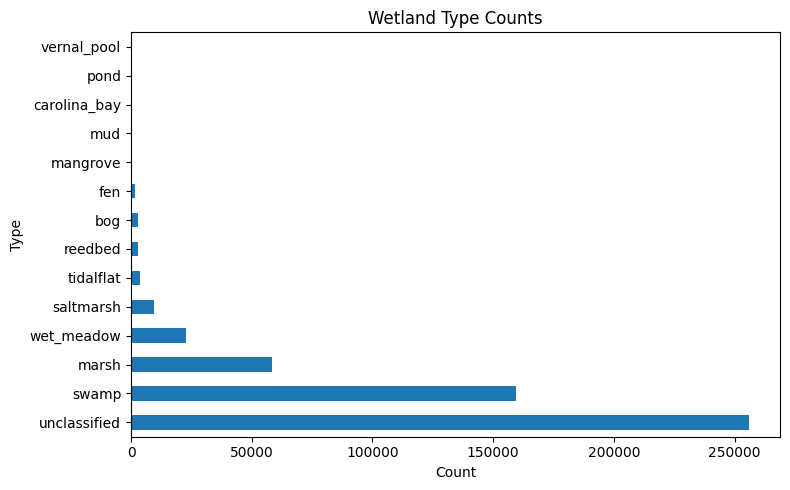

In [19]:
# Wetland Type Counts
df['wetland_normalized'].value_counts().plot(kind='barh', figsize=(8, 5))
plt.title('Wetland Type Counts')
plt.xlabel('Count')
plt.ylabel('Type')
plt.tight_layout()
plt.show()

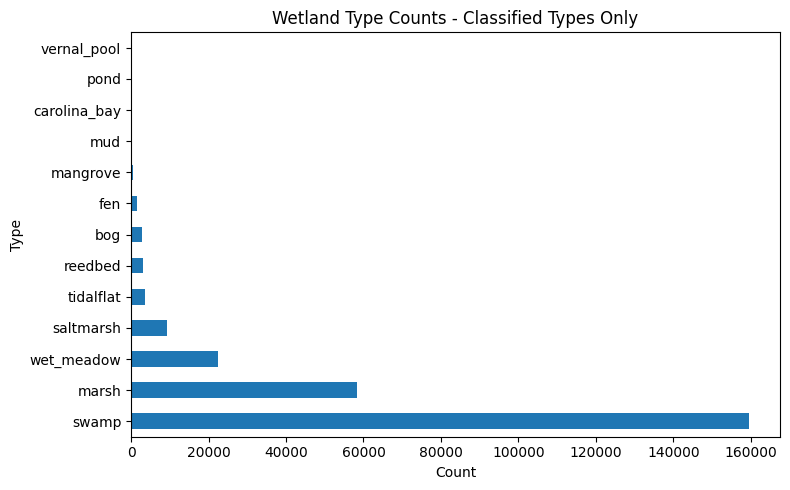

In [20]:
# Wetland Type Counts Excluding Unclassified
df[df['wetland_normalized'] != 'unclassified']['wetland_normalized'].value_counts().plot(kind='barh', figsize=(8, 5))
plt.title('Wetland Type Counts - Classified Types Only')
plt.xlabel('Count')
plt.ylabel('Type')
plt.tight_layout()
plt.show()

In [21]:
region_counts = df['region'].value_counts()
region_counts

region
Northeast    250847
Southeast    213112
Northwest     43849
Southwest      9650
Name: count, dtype: int64

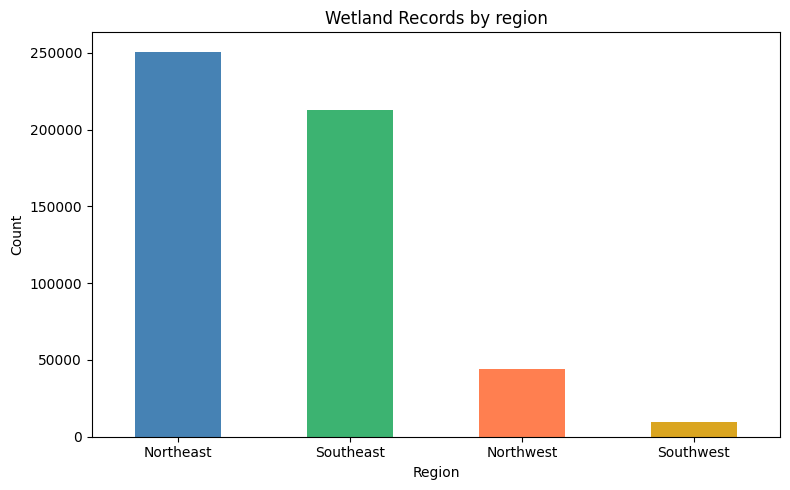

In [22]:
# Wetland Count by Region
region_counts.plot(kind='bar',
                   color=[REGION_COLORS[r] for r in region_counts.index],
                   figsize=(8, 5))
plt.title('Wetland Records by region')
plt.ylabel('Count')
plt.xlabel('Region')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

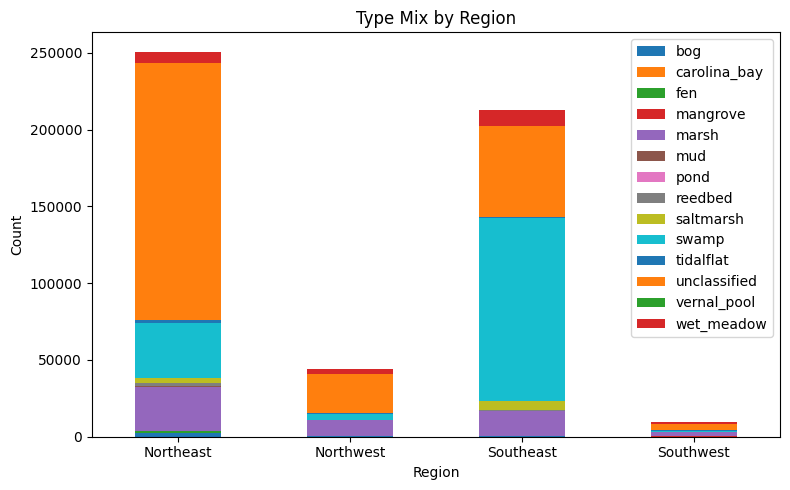

In [23]:
# Wetland Mix by Region
df.groupby(['region', 'wetland_normalized']).size().unstack(fill_value=0).plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title('Type Mix by Region')
plt.ylabel('Count')
plt.xlabel('Region')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

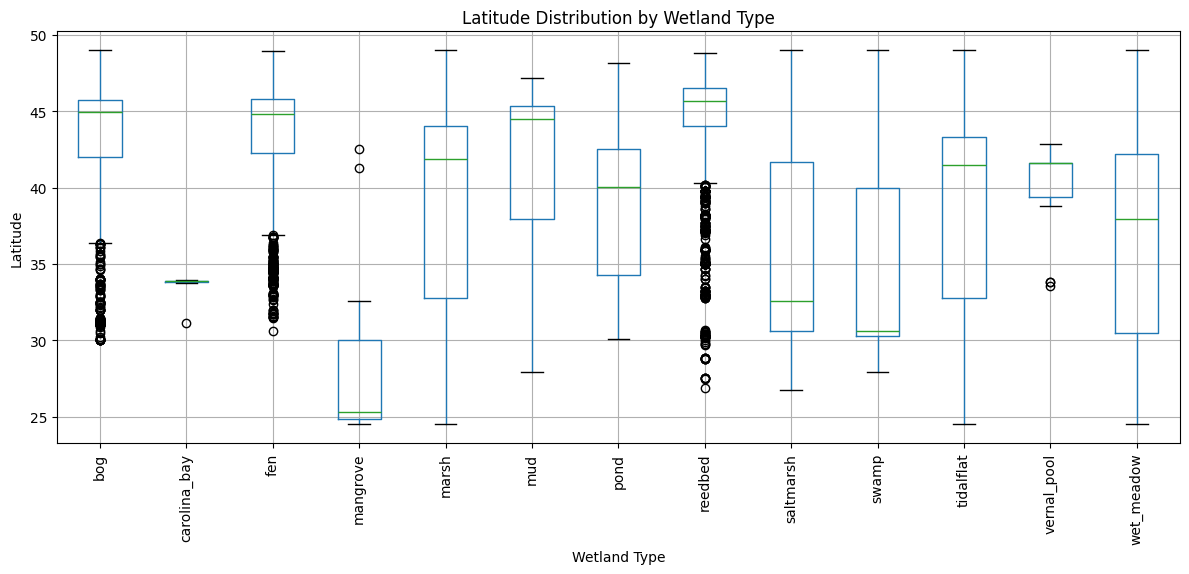

In [24]:
# Latitude Distribution by Wetland Type
df[df['wetland_normalized'] != 'unclassified'].boxplot(
    column='lat', by='wetland_normalized', figsize=(12, 6))
plt.xticks(rotation=90)
plt.suptitle('')
plt.title('Latitude Distribution by Wetland Type')
plt.ylabel('Latitude')
plt.xlabel('Wetland Type')
plt.tight_layout()
plt.show()

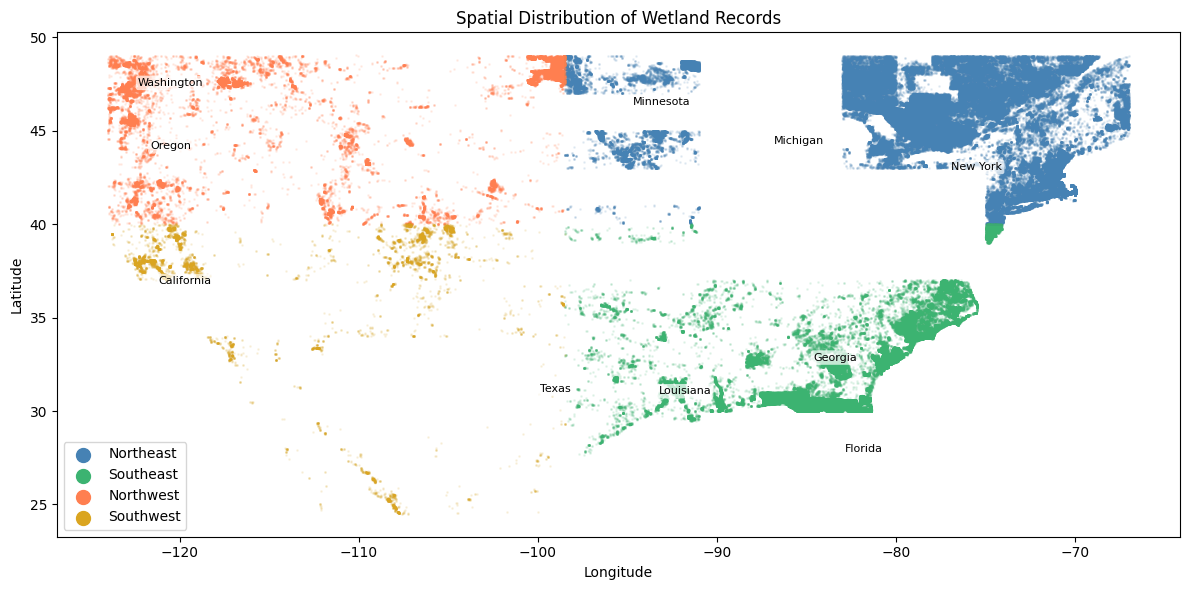

In [25]:
# Spatial Distribution of Wetland Records
# Likely Temporary Until Aggregate with Geopandas, may have some points outside the U.S. here
state_markers = {
    'Florida':      (27.8, -81.8),
    'Georgia':      (32.7, -83.4),
    'Texas':        (31.0, -99.0),
    'California':   (36.8, -119.7),
    'Oregon':       (44.0, -120.5),
    'New York':     (42.9, -75.5),
    'Louisiana':    (30.9, -91.8),
    'Michigan':     (44.3, -85.4),
    'Minnesota':    (46.4, -93.1),
    'Washington':   (47.4, -120.5),
}
fig, ax = plt.subplots(figsize=(12, 6))
for region, color in REGION_COLORS.items():
    subset = df[df['region'] == region]
    ax.scatter(subset['lon'], subset['lat'],
               c=color, alpha=0.1, s=1, label=region)
for state, (lat, lon) in state_markers.items():
    ax.annotate(state, xy=(lon, lat), fontsize=8,
                ha='center', color='black',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none'))
legend = plt.legend(markerscale=10)
for handle in legend.legend_handles:
    handle.set_alpha(1)
plt.title('Spatial Distribution of Wetland Records')
plt.ylabel('Latitude')
plt.xlabel('Longitude')
plt.tight_layout()
plt.show()

In [26]:
# to be continued